In [1]:
import pandas as pd
import numpy as np
import PIL
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-05-09 16:28:27.331486: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-09 16:28:27.331601: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-09 16:28:27.452720: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


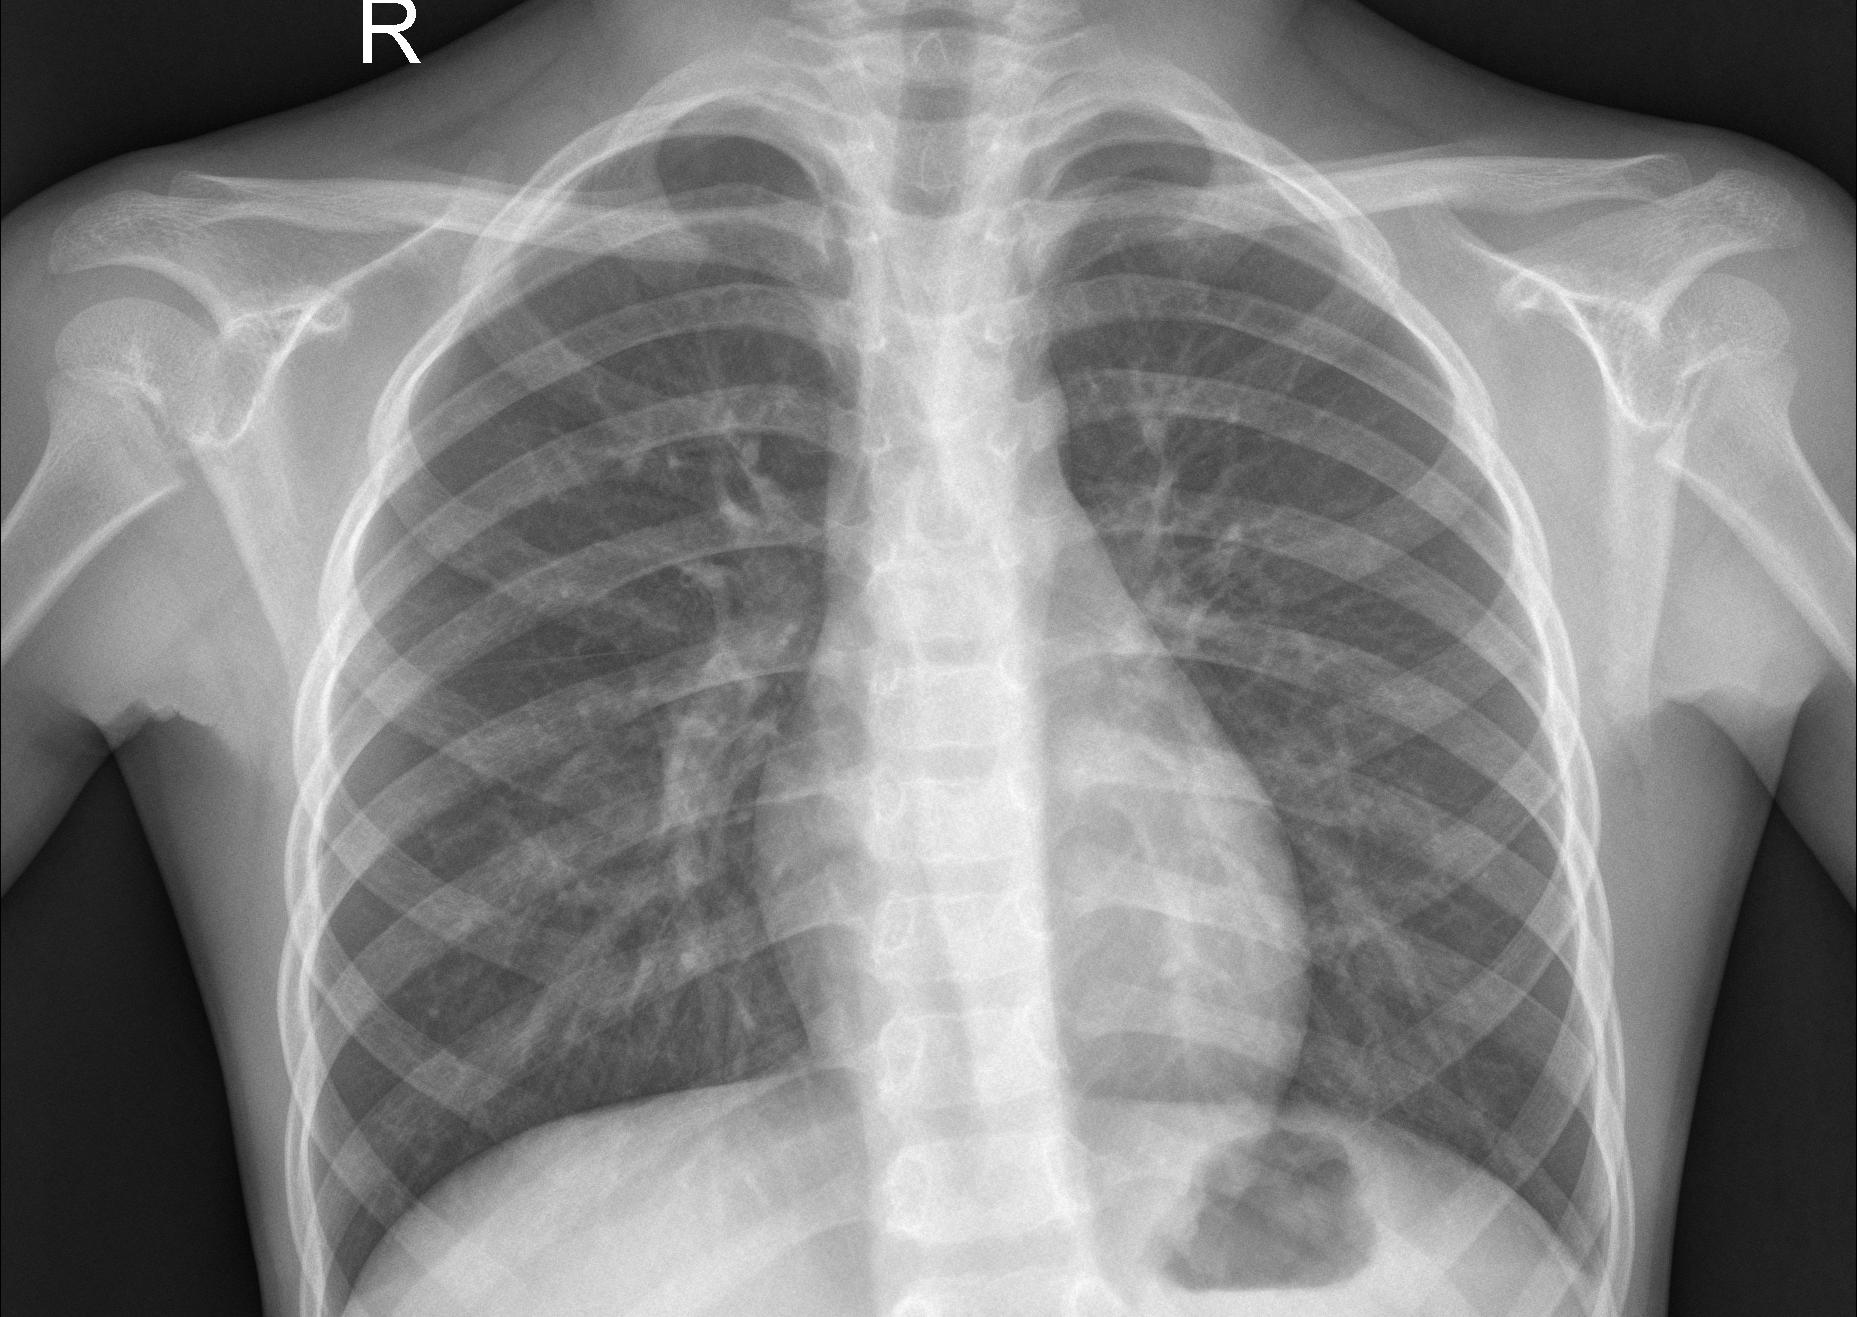

In [3]:
image = PIL.Image.open('/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg')

image

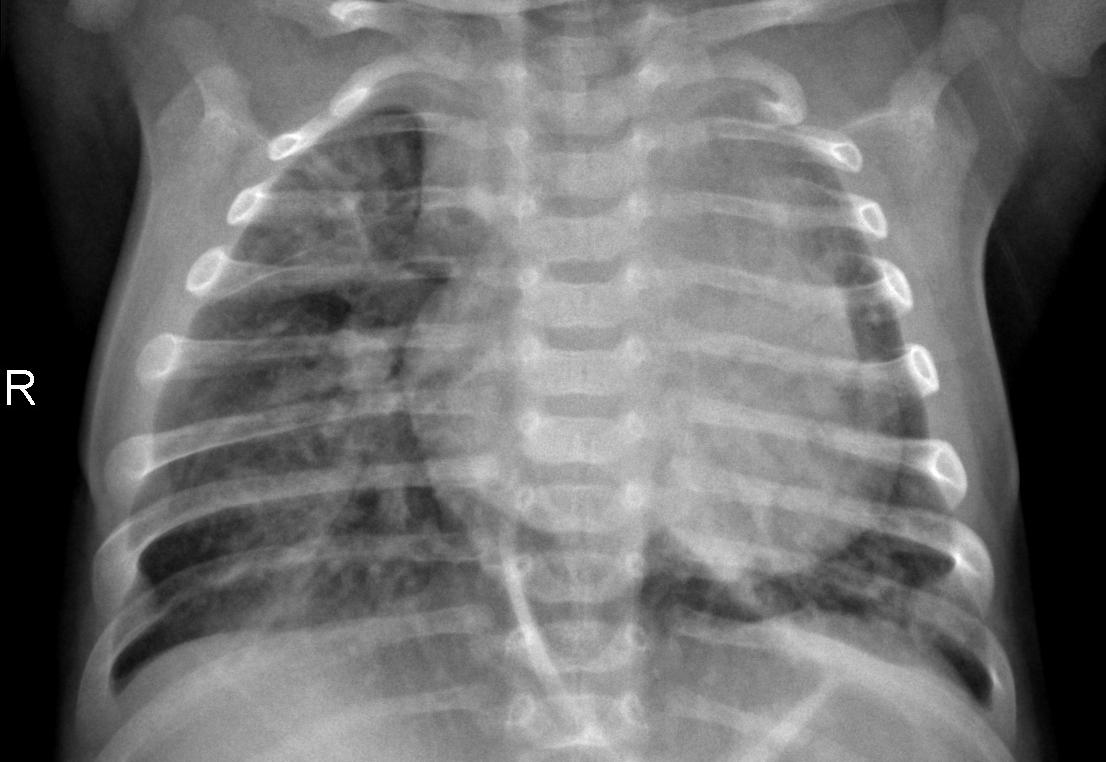

In [4]:
image = PIL.Image.open('/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg')

image

In [5]:
train = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
test = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'
validation = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'

In [6]:
training_generator = ImageDataGenerator(rescale=1/255)

data_train = training_generator.flow_from_directory(train, target_size=(256,256))

Found 5216 images belonging to 2 classes.


In [7]:
validation_generator = ImageDataGenerator(rescale=1/255)

data_valid = validation_generator.flow_from_directory(validation, target_size=(256,256))

Found 16 images belonging to 2 classes.


In [8]:
test_generator = ImageDataGenerator(rescale=1/255)

data_test = test_generator.flow_from_directory(test, target_size=(256,256))

Found 624 images belonging to 2 classes.


## CNN

In [9]:
from tensorflow.keras import regularizers

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',kernel_regularizer=regularizers.l2(0.001),input_shape=(256,256,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    #tf.keras.layers.MaxPooling2D(2,2),
    #tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    #tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    #tf.keras.layers.MaxPooling2D(2,2),
    #tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(256,(3,3),activation='relu'),
    #tf.keras.layers.Conv2D(256,(3,3),activation='relu'),
    #tf.keras.layers.MaxPooling2D(2,2),
    #tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(2,activation='sigmoid')
])

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [11]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['acc','f1_score'])

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 123, 123, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 121, 121, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 119, 119, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 117, 117, 32)   │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 438048)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    28,035,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,755,618 (109.69 MB)

 Trainable params: 28,755,618 (109.69 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
callbacks = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,verbose=1)
#checkpoint = tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

In [14]:
# history = model.fit(data_train,epochs=100,validation_data=data_valid)
history = model.fit(
    data_train,
#     steps_per_epoch=len(data_train),
    epochs=20,
    validation_data=data_valid,
#     validation_steps=len(data_valid)
#     callbacks=[checkpoint]
    callbacks=[callbacks]
)

Epoch 1/20


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1718619285.817645     147 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1718619285.838138     147 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


163/163 ━━━━━━━━━━━━━━━━━━━━ 185s 642ms/step - acc: 0.7465 - f1_score: 0.6302 - loss: 0.5590 - val_acc: 0.8750 - val_f1_score: 0.8730 - val_loss: 0.3451
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 312ms/step - acc: 0.9512 - f1_score: 0.9361 - loss: 0.1667 - val_acc: 1.0000 - val_f1_score: 1.0000 - val_loss: 0.2083
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 313ms/step - acc: 0.9528 - f1_score: 0.9383 - loss: 0.1658 - val_acc: 0.9375 - val_f1_score: 0.9373 - val_loss: 0.1169
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 313ms/step - acc: 0.9572 - f1_score: 0.9442 - loss: 0.1499 - val_acc: 0.7500 - val_f1_score: 0.7333 - val_loss: 0.4781
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 314ms/step - acc: 0.9735 - f1_score: 0.9662 - loss: 0.0941 - val_acc: 0.7500 - val_f1_score: 0.7333 - val_loss: 0.3979
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 316ms/step - acc: 0.9826 - f1_score: 0.9774 - loss: 0.0632 - val_acc: 0.8750 - val_f1_score: 0.8730 - val_loss: 0.1738
Epoch 7/20
163/163 ━━━━━━━━━━━━━

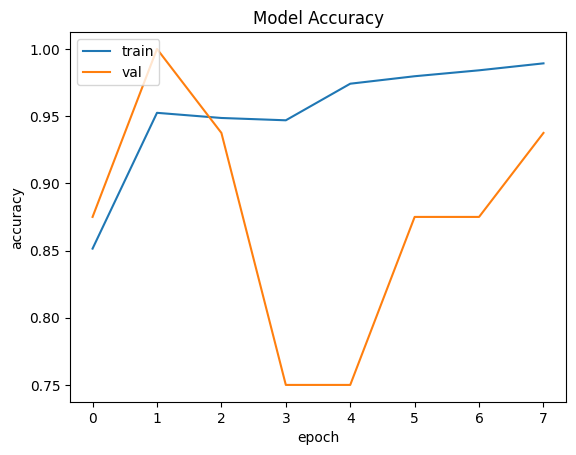

In [15]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model Accuracy'),
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

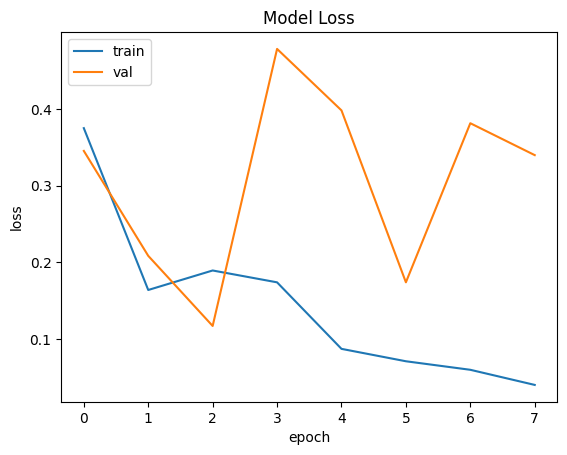

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss'),
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

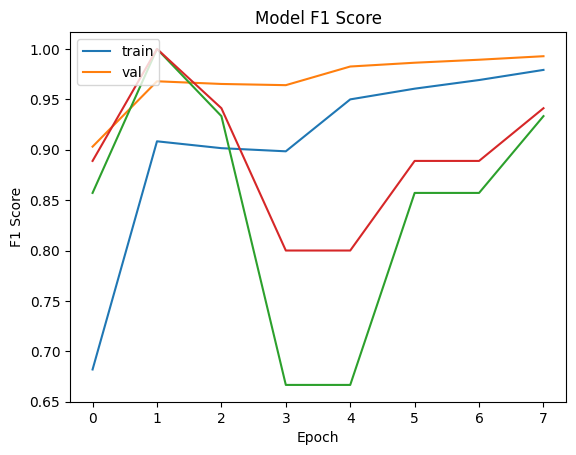

In [17]:
plt.plot(history.history['f1_score'])
plt.plot(history.history['val_f1_score'])
plt.title("Model F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Epoch")
plt.legend(['train','val'],loc="upper left")
plt.show()

In [18]:
results = model.evaluate(data_test,verbose=0)
print(results)

W0000 00:00:1718619767.281876     147 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


[1.6770925521850586, 0.7532051205635071, <tf.Tensor: shape=(2,), dtype=float32, numpy=array([0.5276073, 0.8329717], dtype=float32)>]


In [19]:
print("    Test Loss : {:.5f}".format(results[0]))
print("Test Accuracy : {:.2f}".format(results[1]*100))

    Test Loss : 1.67709
Test Accuracy : 75.32


In [20]:
# pred = model.predict(data_test)
# pred = np.argmax(pred,axis=1)

# labels = (data_test.class_indices)
# labels = dict((v,k) for k,v in labels.items())
# pred - [labels[k] for k in pred]

pred = model.predict(data_test)
pred = np.argmax(pred, axis=1)

labels = data_test.class_indices
labels = {v: k for k, v in labels.items()}

# Corrected line: Assign the modified values to 'pred'
pred = [labels[k] for k in pred]

 2/20 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step 

W0000 00:00:1718619777.186067     150 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step


In [21]:
print(pred)

['PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'NORMAL', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMON

In [22]:
from sklearn.metrics import classification_report

y_test = list(data_test.labels)
# print(y_test)
# Example mapping from class names to numeric labels
class_to_label = {0 :"NORMAL", 1 :"PNEUMONIA"}

# Convert true labels (strings) to numeric labels
numeric_true_labels = [class_to_label.get(label, -1) for label in y_test]

# Now use numeric_true_labels in the classification report
print(classification_report(numeric_true_labels, pred))




              precision    recall  f1-score   support

      NORMAL       0.38      0.15      0.21       234
   PNEUMONIA       0.63      0.85      0.72       390

    accuracy                           0.59       624
   macro avg       0.50      0.50      0.47       624
weighted avg       0.53      0.59      0.53       624



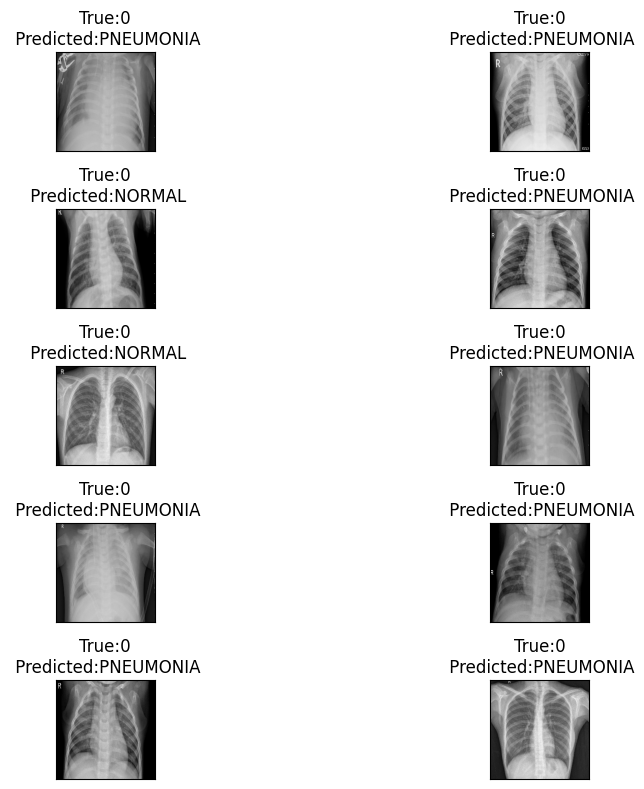

In [23]:
batch_images, batch_labels = next(data_test)

fig,axes = plt.subplots(nrows=5,ncols=2,figsize=(12,8),subplot_kw={'xticks':[],'yticks':[]})

for i, ax in enumerate(axes.flat):
    ax.imshow(batch_images[i])
    ax.set_title(f"True:{data_test.classes[i]}\n Predicted:{pred[i]}")

plt.tight_layout()
plt.show()
                 

In [24]:
my_model = model.save('pneumonia_detection.h5')